In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Encoding
import chardet

# remember to update path

with open("/content/drive/MyDrive/combined.csv", "rb") as f:
    raw = f.read()
    result = chardet.detect(raw)

print(result)


{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [ ]:
# Setting Columns Display
pd.set_option('display.max_columns', None)

In [ ]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/combined.csv", encoding=result["encoding"])
df.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1548381039,1,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1548084169,37,True,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1546427744,37,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1547965054,18,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1546668601,2,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.tail()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
211220,Everyone likes [NAME].,ee6pagw,Senshado,heroesofthestorm,t3_agjf24,t3_agjf24,1547634322,16,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
211221,Well when you’ve imported about a gazillion of...,ef28nod,5inchloser,nottheonion,t3_ak26t3,t3_ak26t3,1548553182,15,False,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
211222,That looks amazing,ee8hse1,springt1me,shittyfoodporn,t3_agrnqb,t3_agrnqb,1547683734,70,False,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
211223,The FDA has plenty to criticize. But like here...,edrhoxh,enamedata,medicine,t3_aejqzd,t1_edrgdtx,1547168832,4,False,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
211224,Desktop link: ^^/r/HelperBot_ ^^Downvote ^^to ...,edze9g4,HelperBot_,MorbidReality,t3_afhw30,t1_edze91s,1547397262,61,True,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(211225, 37)

In [ ]:
df.isna().sum()

,0
text,0
id,0
author,0
subreddit,0
link_id,0
parent_id,0
created_utc,0
rater_id,0
example_very_unclear,0
admiration,0


In [ ]:
t = df.tail(2)
with pd.option_context('display.max_colwidth', None):
    print(t)

                                                                                                                                                        text  \
211223  The FDA has plenty to criticize. But like here, it's usually criticized horribly off base. It needs to grow some balls and actually enforce things.    
211224                                                                           Desktop link: ^^/r/HelperBot_ ^^Downvote ^^to ^^remove. ^^Counter: ^^231558   

             id      author      subreddit    link_id   parent_id  \
211223  edrhoxh   enamedata       medicine  t3_aejqzd  t1_edrgdtx   
211224  edze9g4  HelperBot_  MorbidReality  t3_afhw30  t1_edze91s   

        created_utc  rater_id  example_very_unclear  admiration  amusement  \
211223   1547168832         4                 False           0          0   
211224   1547397262        61                  True           0          0   

        anger  annoyance  approval  caring  confusion  curiosity  desire  \


In [ ]:
# Revoming rows where all labels are 0

lab = df.iloc[:, 9:]

lab_sum = lab.sum(axis=1)
df = df[lab_sum > 0]
# Keep ONLY rows with exactly ONE label
df = df[lab_sum == 1]

/tmp/ipython-input-961269065.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[lab_sum == 1]


In [ ]:
df.tail(2)

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
211222,That looks amazing,ee8hse1,springt1me,shittyfoodporn,t3_agrnqb,t3_agrnqb,1547683734,70,False,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
211223,The FDA has plenty to criticize. But like here...,edrhoxh,enamedata,medicine,t3_aejqzd,t1_edrgdtx,1547168832,4,False,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.isna().sum()

,0
text,0
id,0
author,0
subreddit,0
link_id,0
parent_id,0
created_utc,0
rater_id,0
example_very_unclear,0
admiration,0


In [ ]:
# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords once
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
  # Remove URLs and mentions
    text = re.sub(r"http\S+|www\S+|@\w+", "", text)

    # Lowercase the text
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Remove stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['text_cleaned'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:

emotion_labels = [
    "admiration","amusement","anger","annoyance","approval","caring","confusion",
    "curiosity","desire","disappointment","disapproval","disgust","embarrassment",
    "excitement","fear","gratitude","grief","joy","love","nervousness","optimism",
    "pride","realization","relief","remorse","sadness","surprise","neutral"
]

X = df["text_cleaned"]
y = df[emotion_labels]

In [ ]:
# Picking X
#X = df[['text_cleaned']]
X

,text_cleaned
0,game hurt
2,right dont care fuck em
3,man love reddit
4,name nowhere near falcon
5,right considering important document know damn...
...,...
211219,well im glad youre awful way act make think he...
211220,everyone likes name
211221,well youve imported gazillion country gets ser...
211222,looks amazing


In [ ]:
# Picking y

y

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
211220,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
211221,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
211222,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Label format validation

assert set(y.values.flatten()) <= {0,1}

<Axes: >

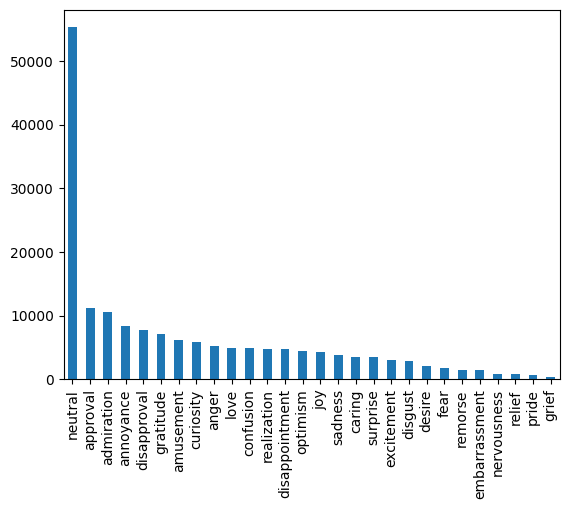

In [ ]:
label_counts = y.sum().sort_values(ascending=False)
label_counts.plot(kind='bar')

In [ ]:
print(label_counts)

neutral           55298
approval          11259
admiration        10531
annoyance          8342
disapproval        7686
gratitude          7075
amusement          6130
curiosity          5885
anger              5202
love               4957
confusion          4938
realization        4714
disappointment     4706
optimism           4519
joy                4329
sadness            3827
caring             3523
surprise           3472
excitement         3020
disgust            2914
desire             2147
fear               1778
remorse            1510
embarrassment      1433
nervousness         796
relief              788
pride               690
grief               351
dtype: int64


In [ ]:
"""from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=[0,1],
    y=y.values.flatten()
)
"""

"from sklearn.utils.class_weight import compute_class_weight\n\nweights = compute_class_weight(\n    class_weight='balanced',\n    classes=[0,1],\n    y=y.values.flatten()\n)\n"

In [ ]:
"""for key, val in X.items():
    print(val)"""

'for key, val in X.items():\n    print(val)'

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [ ]:
# Buiding Models Pipeline and Data Spliting

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

pipeMNB = Pipeline([('tfidg', TfidfVectorizer()), ('clf', OneVsRestClassifier(MultinomialNB()))])
pipeCNB = Pipeline([('tfidg', TfidfVectorizer()), ('clf', OneVsRestClassifier(ComplementNB()))])

In [ ]:
X_train = X_train.squeeze()
X_test  = X_test.squeeze()

X_train

,text_cleaned
199338,nasty nasty nasty really cant understand lb human
114665,u damn clown prolly felt embarrassed youre lik...
205210,unless abusive ldr
107843,worried taken table
150949,wanted bring others awareness site absurd name...
...,...
147357,yeh check like didnt post kept
127434,feel dad curled end bed like loyal dog
162228,youre liar
180540,remember people thought name could handle job


In [ ]:
# Training and Testing
pipeMNB.fit(X_train, y_train)
predictMNB = pipeMNB.predict(X_test)
scoreMNB = classification_report(y_test, predictMNB)

print(f"Multinomial NB's F1 Score: {f1_score(y_test, predictMNB, average='macro')}")
print(scoreMNB)


pipeCNB.fit(X_train, y_train)
predictCNB = pipeCNB.predict(X_test)
scoreCNB = classification_report(y_test, predictCNB)

print(f" Complement NB's F1 Score: {f1_score(y_test, predictCNB, average='macro')}")
print(scoreCNB)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Multinomial NB's F1 Score: 0.018122847286665855
              precision    recall  f1-score   support

           0       0.62      0.02      0.03      3153
           1       0.54      0.01      0.02      1816
           2       0.56      0.00      0.01      1493
           3       0.15      0.00      0.00      2470
           4       0.24      0.00      0.01      3446
           5       0.00      0.00      0.00      1047
           6       0.25      0.00      0.00      1462
           7       0.29      0.00      0.00      1759
           8       0.00      0.00      0.00       637
           9       0.50      0.00      0.00      1430
          10       0.14      0.00      0.00      2350
          11       0.50      0.00      0.00       911
          12       0.00      0.00      0.00       432
          13       0.00      0.00      0.00       865
          14       0.00      0.00      0.00       551
          15       0.92      0.11      0.20      2115
          16       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(f" Accuracy MNB: {accuracy_score(y_test, predictMNB)*100}")
print(f" Accuracy CNB: {accuracy_score(y_test, predictCNB)*100}")

 Accuracy MNB: 4.6502153416365966
 Accuracy CNB: 16.051681992783145


In [ ]:
print(f" Precision MNB: {precision_score(y_test, predictMNB, average='macro')*100}")
print(f" Precision CNB: {precision_score(y_test, predictCNB, average='macro')*100}")

 Precision MNB: 24.41273222350952
 Precision CNB: 8.296006887096013


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(f" Recall MNB: {recall_score(y_test, predictMNB, average='macro')*100}")
print(f" Recall CNB: {recall_score(y_test, predictCNB, average='macro')*100}")

 Recall MNB: 1.0300431982415175
 Recall CNB: 21.73863658811894


In [ ]:
# Logistic Regression
pipeLR = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500000,
                              ngram_range=(1,3))),
    ('clf', OneVsRestClassifier(
        LogisticRegression(random_state=42,
            multi_class='multinomial',
            max_iter=2000,
            solver='lbfgs',
            class_weight='balanced',
            n_jobs=-1
        )
    ))
])

In [ ]:
pipeLR.fit(X_train, y_train)
predLR = pipeLR.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

In [ ]:
print(f"Accuracy LR: {accuracy_score(y_test, predLR)*100}")
print(f"Logistic Regression F1: {f1_score(y_test, predLR, average="macro")*100}")

Accuracy LR: 21.947386800139682
Logistic Regression F1: 29.28142564161264


In [ ]:
print(f" Precision LR: {precision_score(y_test, predLR, average='macro')*100}")
print(f" Recall LR: {recall_score(y_test, predLR, average='macro')*100}")

 Precision LR: 22.25935135249173
 Recall LR: 43.783914048423775


In [ ]:
# Linear SVC
pipeSVM = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500000,
                              min_df=5,
                              max_df=0.9,
                              ngram_range=(1,3),
                              sublinear_tf=True)),
    ('clf', OneVsRestClassifier(
        LinearSVC(random_state=42,
                  C =0.1,
            class_weight='balanced'
        )
    ))
])

"""
param_grid = {
    'tfidf__max_features': [5000, 50000, 500000],
    'clf__estimator__C' :               [0.1, 1, 10]
}
grid = GridSearchCV(pipeSVM, param_grid, scoring='f1_macro', cv=5, n_jobs=-1)

grid.fit(X_train, y_train)""" # run to find the best parameters


"\nparam_grid = {\n    'tfidf__max_features': [5000, 50000, 500000],\n    'clf__estimator__C' :               [0.1, 1, 10]\n}\ngrid = GridSearchCV(pipeSVM, param_grid, scoring='f1_macro', cv=5, n_jobs=-1)\n\ngrid.fit(X_train, y_train)"

In [ ]:
pipeSVM.fit(X_train, y_train)
predSVM = pipeSVM.predict(X_test)



In [ ]:

print(f"Accuracy SVM: {accuracy_score(y_test, predSVM)*100}")
print("SVM F1:", f1_score(y_test, predSVM, average="macro")*100)



Accuracy SVM: 8.25864276568502
SVM F1: 25.717390620104077


In [ ]:
print(f" Precision SVM: {precision_score(y_test, predSVM, average='macro')*100}")
print(f" Recall SVM: {recall_score(y_test, predSVM, average='macro')*100}")

 Precision SVM: 17.548474852872314
 Recall SVM: 53.2777807479634


"""Before doing anything for imbalance"""

Multinomial NB F1 : 0.02317192261458027

Complement NB F1 Score: 0.14292308224116584

Logistic Regression F1: 0.16332216194431326

SVM F1: 0.2208333800026048

"""With balanced weights (LR, SVM)"""

Logistic Regression F1: 0.2743023119409042

SVM F1: 0.27148862676543406

"""After adding (n_gram=(1,3))"""

Logistic Regression F1: 0.30454710937461543

SVM F1: 0.3083254682539061

Since these models aren't doing so well, let's move to RNN

In [ ]:
import random
import datetime
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard

In [ ]:
"""RNN but with num of words = 50000, batch size = 64, epochs = 20, validation split = 0.1
"""
"""
# Tokenize
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

# Build RNN
model = Sequential([
    Embedding(input_dim=50000, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(28, activation='softmax')  # 28 emotions
])

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train_pad, y_train.values, batch_size=128, epochs=100, validation_split=0.1, callbacks=[tensorboard_callback])
"""


"\n# Tokenize\ntokenizer = Tokenizer(num_words=50000)\ntokenizer.fit_on_texts(X_train)\nX_train_seq = tokenizer.texts_to_sequences(X_train)\nX_test_seq  = tokenizer.texts_to_sequences(X_test)\n\n# Pad sequences\nmax_len = 100\nX_train_pad = pad_sequences(X_train_seq, maxlen=max_len)\nX_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)\n\n# Build RNN\nmodel = Sequential([\n    Embedding(input_dim=50000, output_dim=128, input_length=max_len),\n    LSTM(128, return_sequences=False),\n    Dropout(0.5),\n    Dense(28, activation='softmax')  # 28 emotions\n])\n\n# Compile\nmodel.compile(\n    loss='categorical_crossentropy',\n    optimizer='adam',\n    metrics=['accuracy']\n)\n\n# Train\nes = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)\nhistory = model.fit(X_train_pad, y_train.values, batch_size=128, epochs=100, validation_split=0.1, callbacks=[tensorboard_callback])\n"

In [ ]:
from sklearn.utils import class_weight

# Tackling Class Imbalance
y_integers = np.argmax(y_train.values, axis=1)

# Calculate weights: Rare classes get higher weights, common classes get lower.
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)
dampened_weights = np.sqrt(class_weights)
# Convert to dictionary format
class_weight_dict = dict(enumerate(dampened_weights))

print(f"Weight for Class 27 (Neutral): {class_weight_dict.get(27, 'N/A'):.2f}")
print(f"Weight for Class 15 (Gratitude): {class_weight_dict.get(15, 'N/A'):.2f}")

# Tokenize
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

# Build RNN
model = Sequential([
    Embedding(input_dim=50000, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(28, activation='softmax')  # 28 emotions
])

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# --- 3. Train with Weights
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad,
    y_train.values,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    callbacks=[es],
    class_weight=class_weight_dict
)

Weight for Class 27 (Neutral): 0.33
Weight for Class 15 (Gratitude): 0.93


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.3485 - loss: 2.5910 - val_accuracy: 0.4210 - val_loss: 2.2536
Epoch 2/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.4168 - loss: 1.9989 - val_accuracy: 0.3931 - val_loss: 2.2180
Epoch 3/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.4403 - loss: 1.7426 - val_accuracy: 0.3759 - val_loss: 2.2461
Epoch 4/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.4660 - loss: 1.5687 - val_accuracy: 0.3665 - val_loss: 2.3580
Epoch 5/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.4843 - loss: 1.4453 - val_accuracy: 0.3538 - val_loss: 2.4674


Implemented early stopping to avoid overfitting, training stopped after 6 epochs

In [ ]:
# Test and Metrics
predRNN_prob = model.predict(X_test_pad)
predRNN = (predRNN_prob > 0.5).astype(int)  # threshold = 0.5


print("RNN F1 :", f1_score(y_test, predRNN, average='macro')*100)
print(classification_report(y_test, predRNN))


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
RNN F1 : 21.04748274386709
              precision    recall  f1-score   support

           0       0.59      0.42      0.49      3153
           1       0.59      0.46      0.52      1816
           2       0.48      0.15      0.23      1493
           3       0.67      0.00      0.01      2470
           4       0.70      0.01      0.02      3446
           5       0.35      0.08      0.13      1047
           6       0.70      0.02      0.03      1462
           7       0.40      0.08      0.14      1759
           8       0.41      0.18      0.25       637
           9       0.75      0.00      0.00      1430
          10       0.67      0.00      0.00      2350
          11       0.54      0.12      0.19       911
          12       0.46      0.10      0.17       432
          13       0.32      0.13      0.19       865
          14       0.54      0.29      0.38       551
          15       0.87      0.70      0.78      2115
          1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RNN F1 : 0.22634391494829026

F1 decreased to 0.1401858520809724



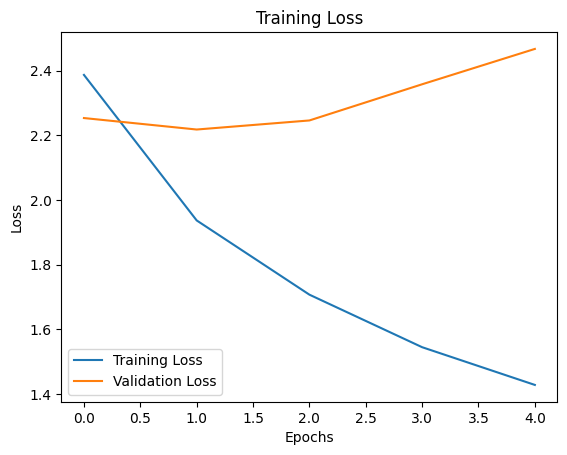

In [ ]:
# Plotting Trainig Loss
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training Loss"); plt.show()

Let's try to improve our deep learning model.

In [ ]:
"Let's try a Bidirectional model"
from tensorflow.keras.layers import Bidirectional


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

# Tokenization

vocab_size_1 = 50000
max_len_1 = 150

tokenizer_1 = Tokenizer(num_words=vocab_size_1)
tokenizer_1.fit_on_texts(X_train)

X_train_seq_1 = tokenizer_1.texts_to_sequences(X_train)
X_test_seq_1  = tokenizer_1.texts_to_sequences(X_test)

X_train_pad_1 = pad_sequences(X_train_seq_1, maxlen=max_len_1, padding='post')
X_test_pad_1  = pad_sequences(X_test_seq_1, maxlen=max_len_1, padding='post')

# Bidirectional LSTM Model

model_1 = Sequential([
    Embedding(input_dim=vocab_size_1, output_dim=128, input_length=max_len_1),

    Bidirectional(LSTM(
        128,
        return_sequences=True,
        dropout=0.2
    )),
    BatchNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(64, dropout=0.2)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(28, activation='softmax')
])


model_1.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_1.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train

rlrop = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

history_1 = model_1.fit(
    X_train_pad_1,
    y_train.values,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    callbacks=[es, rlrop],
    class_weight=class_weight_dict
)


Epoch 1/15
846/846 ━━━━━━━━━━━━━━━━━━━━ 69s 76ms/step - accuracy: 0.1540 - loss: 3.0478 - val_accuracy: 0.4020 - val_loss: 2.3652 - learning_rate: 0.0010
Epoch 2/15
846/846 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.3781 - loss: 2.2501 - val_accuracy: 0.3425 - val_loss: 2.3667 - learning_rate: 0.0010
Epoch 3/15
846/846 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.3967 - loss: 2.0306 - val_accuracy: 0.3586 - val_loss: 2.3250 - learning_rate: 0.0010
Epoch 4/15
846/846 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.4087 - loss: 1.8923 - val_accuracy: 0.3422 - val_loss: 2.3309 - learning_rate: 0.0010
Epoch 5/15
846/846 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.4210 - loss: 1.7905 - val_accuracy: 0.3406 - val_loss: 2.3516 - learning_rate: 0.0010
Epoch 6/15
846/846 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.4431 - loss: 1.6808 - val_accuracy: 0.3515 - val_loss: 2.3547 - learning_rate: 3.0000e-04


In [ ]:


# Predict probabilities
probs_1 = model_1.predict(X_test_pad_1)

# Tune thresholds for each label
best_thresh = []
for i in range(28):
    best_t = 0.5
    best_f1 = 0
    for t in np.arange(0.1, 0.9, 0.02):
        preds_t = (probs_1[:, i] > t).astype(int)
        f1 = f1_score(y_test.iloc[:, i], preds_t)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresh.append(best_t)

best_thresh = np.array(best_thresh)
print(best_thresh)


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step
[0.3  0.24 0.3  0.1  0.12 0.2  0.1  0.18 0.62 0.1  0.1  0.18 0.26 0.52
 0.4  0.14 0.1  0.32 0.48 0.1  0.3  0.14 0.1  0.18 0.24 0.2  0.2  0.1 ]


In [ ]:
pred_1 = (probs_1 > best_thresh.reshape(1, -1)).astype(int)

print("Bidirectional 2.0 F1 :", f1_score(y_test, pred_1, average='macro')*100)
print(classification_report(y_test, pred_1))

Bidirectional 2.0 F1 : 30.227428717848564
              precision    recall  f1-score   support

           0       0.49      0.52      0.51      3153
           1       0.49      0.63      0.55      1816
           2       0.30      0.32      0.31      1493
           3       0.14      0.31      0.19      2470
           4       0.14      0.33      0.19      3446
           5       0.20      0.24      0.22      1047
           6       0.15      0.25      0.19      1462
           7       0.16      0.29      0.21      1759
           8       0.38      0.25      0.30       637
           9       0.14      0.17      0.16      1430
          10       0.18      0.22      0.20      2350
          11       0.27      0.27      0.27       911
          12       0.28      0.22      0.25       432
          13       0.25      0.16      0.20       865
          14       0.44      0.45      0.45       551
          15       0.84      0.74      0.79      2115
          16       0.05      0.11      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1 improved to 0.32115977581995897

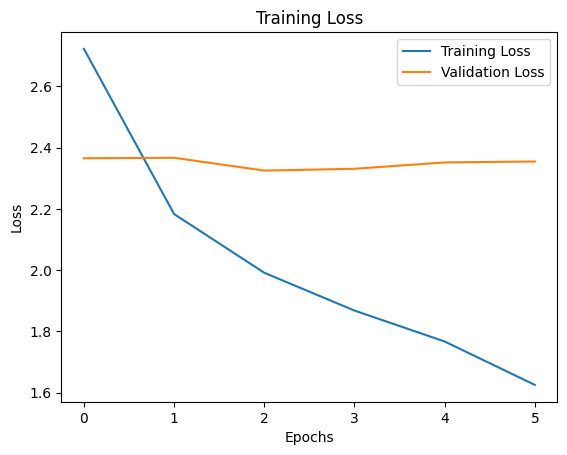

In [ ]:
# Plotting Trainig Loss
plt.plot(history_1.history['loss'], label="Training Loss")
plt.plot(history_1.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training Loss"); plt.show()

In [ ]:
import shap
import numpy as np
import pandas as pd
from collections import defaultdict

# Map token indices back to words
index_to_word_1 = {v: k for k, v in tokenizer_1.word_index.items()}

def shap_top_words_per_label(model, X_data, tokenizer, n_samples=100, top_k=10):
    """
    Compute SHAP values and correctly aggregate them by specific token instances.
    """
    # 1. Subset for speed
    X_subset = X_data[:n_samples]

    # 2. Define a wrapper to ensure output is compatible with SHAP
    # SHAP sometimes passes floats; we must cast to int for Embedding layers
    def model_predict(x):
        return model.predict(x.astype(int))

    # 3. Create SHAP explainer
    # masking='' tells SHAP to mask by removing tokens (handling variable length)
    # If this fails, try shap.DeepExplainer (see note below)
    explainer = shap.Explainer(model_predict, X_subset)

    # Calculate SHAP values
    shap_values = explainer(X_subset)

    # 4. Handle Shape Variations
    # SHAP .values is usually (n_samples, seq_len, n_classes) for this setup
    vals = shap_values.values
    if isinstance(vals, list):
        # Sometimes returns list of arrays, stack them to (n_samples, seq_len, n_classes)
        vals = np.stack(vals, axis=-1)

    top_words_per_label = {}

    # 5. Iterate over each label (Emotion)
    num_labels = vals.shape[-1]

    for label_idx in range(num_labels):

        # Dictionaries to store total impact and frequency of each word for THIS label
        word_impact_sum = defaultdict(float)
        word_counts = defaultdict(int)

        # Iterate through every sample and every token position
        for sample_i in range(n_samples):
            for seq_j in range(X_subset.shape[1]):

                # Get the token ID and the specific SHAP value for this instance
                token_id = int(X_subset[sample_i, seq_j])

                # Skip padding (0)
                if token_id == 0:
                    continue

                # The exact contribution of this word, in this sentence, to this emotion
                shap_val = vals[sample_i, seq_j, label_idx]

                # Decode word
                word = index_to_word_1.get(token_id, "[UNK]")

                # Accumulate
                word_impact_sum[word] += shap_val
                word_counts[word] += 1

        # Calculate average SHAP value per word
        avg_word_scores = {}
        for word, total_shap in word_impact_sum.items():
            avg_word_scores[word] = total_shap / word_counts[word]

        # Sort by highest positive contribution
        sorted_words = sorted(avg_word_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        top_words_per_label[label_idx] = sorted_words

    return top_words_per_label

# --- Run the function ---
# Note: n_samples=100 might be slow. Try 10 first to test.
results = shap_top_words_per_label(model_1, X_test_pad_1, tokenizer_1, n_samples=10, top_k=5)

# --- Print Results ---
label_cols = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
              'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
              'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
              'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
              'relief', 'remorse', 'sadness', 'surprise', 'neutral']

for idx, words in results.items():
    emotion_name = label_cols[idx]
    print(f"\nExample words driving '{emotion_name}':")
    for word, score in words:
        print(f"  {word}: {score:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━

PermutationExplainer explainer:  40%|████      | 4/10 [00:00<?, ?it/s]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


PermutationExplainer explainer:  60%|██████    | 6/10 [00:13<00:04,  1.08s/it]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


PermutationExplainer explainer: 100%|██████████| 10/10 [00:24<00:00,  2.39s/it]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


PermutationExplainer explainer: 11it [00:26,  3.76s/it]


Example words driving 'admiration':
  congratulations: 0.2067
  nice: 0.1998
  appreciate: 0.1916
  worth: 0.0497
  work: 0.0364

Example words driving 'amusement':
  lips: 0.0627
  lick: 0.0199
  every: 0.0119
  comments: 0.0116
  makes: 0.0106

Example words driving 'anger':
  freaking: 0.0193
  argument: 0.0189
  taking: 0.0179
  farther: 0.0118
  way: 0.0074

Example words driving 'annoyance':
  taking: 0.0177
  freaking: 0.0141
  doesnt: 0.0136
  argument: 0.0135
  farther: 0.0122

Example words driving 'approval':
  anything: 0.0311
  way: 0.0246
  worth: 0.0230
  belive: 0.0211
  look: 0.0178

Example words driving 'caring':
  sobriety: 0.0369
  needed: 0.0317
  taking: 0.0301
  belive: 0.0217
  get: 0.0209

Example words driving 'confusion':
  understand: 0.0864
  didnt: 0.0524
  thing: 0.0145
  freaking: 0.0129
  may: 0.0128

Example words driving 'curiosity':
  freaking: 0.0793
  cursor: 0.0719
  sounded: 0.0423
  goes: 0.0361
  didnt: 0.0355

Example words driving 'desire':

In [ ]:
print(f"Accuracy RNN : {accuracy_score(y_test, predRNN)*100}")
print(f"Accuracy BiRNN : {accuracy_score(y_test, pred_1)*100}")

Accuracy RNN : 14.596670934699105
Accuracy BiRNN : 24.55088658673806


In [ ]:
print(f"Precision RNN: {precision_score(y_test, predRNN, average='macro')*100}")
print(f"Recall RNN: {recall_score(y_test, predRNN, average='macro')*100}")
print(f"Precision BiRNN: {precision_score(y_test, pred_1, average='macro')*100}")
print(f"Recall BiRNN: {recall_score(y_test, pred_1, average='macro')*100}")

Precision RNN: 53.55948388594545
Recall RNN: 16.849384227235316
Precision BiRNN: 29.64148198623171
Recall BiRNN: 33.25707316954517
